In [ ]:
pip install -U scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.4 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier
import matplotlib as mpl
import time

# plot settings
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

**Task 1: Dataset Exploration**
* Load Fashion-MNIST.
* Print dataset dimensions.
* Display ten sample images.
* Plot class distribution

In [ ]:
#  Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
#  Display dataset dimensions
print("Training Images :", X_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", X_test.shape)
print("Testing Labels  :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images  : (10000, 28, 28)
Testing Labels  : (10000,)


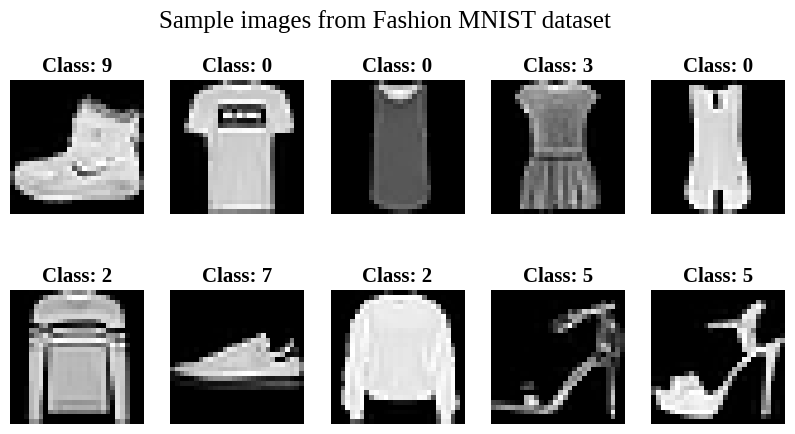

<Figure size 640x480 with 0 Axes>

In [10]:
# Display 10 sample images
plt.figure(figsize=(10,5))
plt.suptitle("Sample images from Fashion MNIST dataset")
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Class: {y_train[i]}")
    plt.axis("off")
plt.show()
plt.savefig("SampleImages.eps", format="eps", bbox_inches="tight")

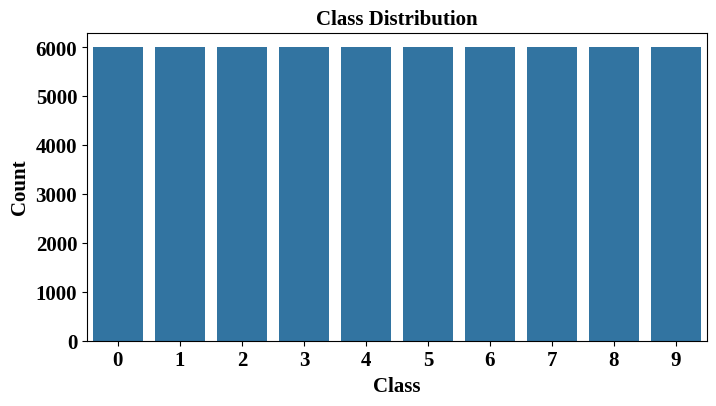

In [11]:
# Plot class distribution
plt.figure(figsize=(8,4))
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("ClassDistribution.eps", format="eps", bbox_inches="tight")
plt.show()

**Task 2: Data Preprocessing**
* Flatten images.
* Normalize pixel values.
* Print tensor shapes before and after preprocessing.

In [12]:
# Print shape of dataset before preprocessing
print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
# Flatten images and normalizr pixels to [0,1]
X_train = X_train.reshape(-1, 784).astype("float32") / 255
X_test = X_test.reshape(-1, 784).astype("float32") / 255
#  Convert labels to one-hot encoded vectors
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("\nAfter preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train_cat.shape)
print("y_test :", y_test_cat.shape)

Before preprocessing:
X_train: (60000, 28, 28)
X_test : (10000, 28, 28)

After preprocessing:
X_train: (60000, 784)
X_test : (10000, 784)
y_train: (60000, 10)
y_test : (10000, 10)


**Task 3: Model Construction**
* Construct an MLP with
    * Input layer (784)
    * Dense(128, ReLU)
    * Dense(64, ReLU)
    * Dense(10, Softmax)
* Display model.summary().

**Task 4: Model Training**
* Compile using
    * Optimizer: Adam
    * Loss: Categorical Cross Entropy
    * Metric: Accuracy
* Train for 20 epochs with batch size 32

In [13]:
# Model construction
model = Sequential()

model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Train model for 20 epochs with batch size 32
start = time.time()
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)
# Calculate time taken for training
baseline_time = time.time() - start

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8184 - loss: 0.5063 - val_accuracy: 0.8589 - val_loss: 0.3882
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8626 - loss: 0.3732 - val_accuracy: 0.8692 - val_loss: 0.3600
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8740 - loss: 0.3348 - val_accuracy: 0.8700 - val_loss: 0.3571
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8840 - loss: 0.3106 - val_accuracy: 0.8807 - val_loss: 0.3399
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8901 - loss: 0.2924 - val_accuracy: 0.8856 - val_loss: 0.3226
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8948 - loss: 0.2782 - val_accuracy: 0.8851 - val_loss: 0.3221
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8986 - loss: 0.2647 - val_accuracy: 0.8805 - val_loss: 0.3386
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9047 - loss: 0.2520 

**Task 5: Model Evaluation**

Compute
* Accuracy
* Precision
* Recall
* F1-score
* Confusion Matrix
* Classification Report

**Generate the following plots**
* Training Accuracy vs Epoch
* Validation Accuracy vs Epoch
* Training Loss vs Epoch
* Validation Loss vs Epoch
* Confusion Matrix

In [32]:
# Compute accuracy, precision,recall, f1-score
pred = model.predict(X_test)

y_pred = np.argmax(pred,axis=1)
baseline_acc = accuracy_score(y_test,y_pred)
baseline_precision=precision_score(y_test,y_pred,average='weighted')
baseline_recall=recall_score(y_test,y_pred,average='weighted')
baseline_f1 = f1_score(y_test,y_pred,average='weighted')

print("Accuracy :",baseline_acc)
print("Precision:",baseline_precision)
print("Recall   :",baseline_recall)
print("F1 Score :",baseline_f1)

Accuracy : 0.8892
Precision: 0.8889273373099608
Recall   : 0.8892
F1 Score : 0.8886526217515944


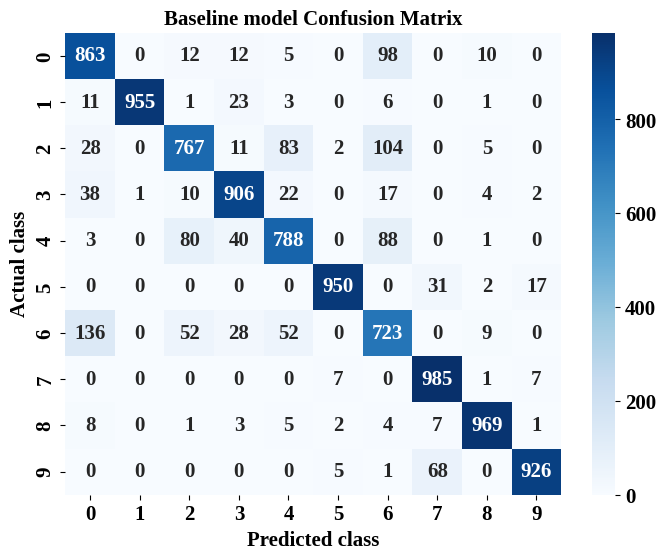

<Figure size 640x480 with 0 Axes>

In [16]:
# Plot confusion matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Baseline model Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()
plt.savefig("BaselineModelConfusionMatrix.eps", format="eps", bbox_inches="tight")

In [17]:
# Print classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.86      0.83      1000
           1       1.00      0.95      0.98      1000
           2       0.83      0.77      0.80      1000
           3       0.89      0.91      0.90      1000
           4       0.82      0.79      0.80      1000
           5       0.98      0.95      0.97      1000
           6       0.69      0.72      0.71      1000
           7       0.90      0.98      0.94      1000
           8       0.97      0.97      0.97      1000
           9       0.97      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



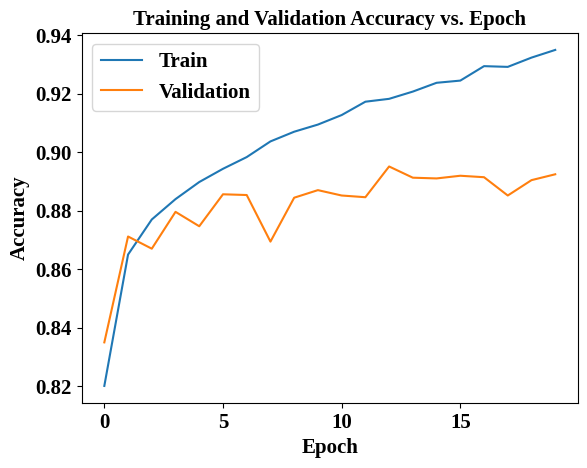

<Figure size 640x480 with 0 Axes>

In [18]:
# Plot Training and Validation Accuracy vs. Epoch
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title("Training and Validation Accuracy vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.savefig("TrainingValidationAccuracyVsEpoch.eps", format="eps", bbox_inches="tight")

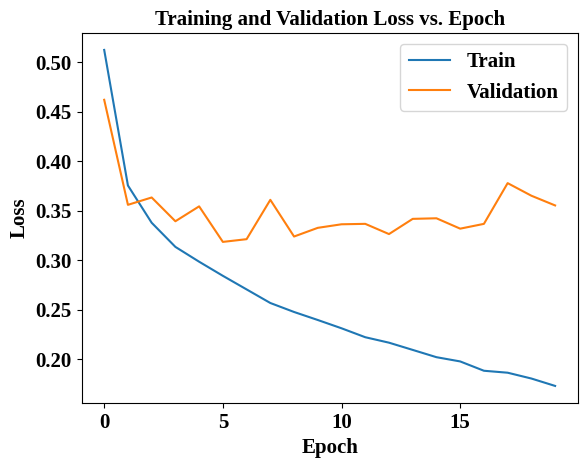

<Figure size 640x480 with 0 Axes>

In [19]:
# Plot Training and Validation Loss vs. Epoch
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.title("Training and Validation Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
plt.savefig("TrainingValidationLossVsEpoch.eps", format="eps", bbox_inches="tight")

#  Hyperparameter Optimization
## Task 1: Build a baseline MLP model.


In [20]:
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 activation='relu',
                 optimizer='adam',
                 learning_rate=0.001,
                 dropout_rate=0.0):

    model = Sequential()

    model.add(Dense(hidden_neurons,
                    activation=activation,
                    input_shape=(784,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    for i in range(hidden_layers-1):

        model.add(Dense(hidden_neurons,
                        activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10,
                    activation='softmax'))

    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)

    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)

    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [21]:
model = KerasClassifier(
    model=create_model,
    verbose=0
)

## Task 2: Define the hyperparameter search space.


In [22]:
param_dist = {
    "model__hidden_layers":[1,2,3],
    "model__hidden_neurons":[32,64,128,256],
    "model__learning_rate":[0.1,0.01,0.001],
    "model__activation":["relu","tanh","sigmoid"],
    "model__optimizer":["adam","sgd","rmsprop"],
    "batch_size":[16,32,64,128],
    "epochs":[10,20,30],
    "model__dropout_rate":[0.0,0.2,0.5]
}

## Task 3: Perform Randomized Search using 5-fold cross-validation.


In [ ]:
random = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    cv=3,
    n_iter=5,
    random_state=42,
    scoring='accuracy'
)
random.fit(X_train,y_train_cat)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

## Task 4: Record the best hyperparameter combination.


In [24]:
best_params = random.best_params_
print("Best Parameters")
print("Hidden Layers :", best_params["model__hidden_layers"])
print("Hidden Neurons:", best_params["model__hidden_neurons"])
print("Learning Rate :", best_params["model__learning_rate"])
print("Batch Size    :", best_params["batch_size"])
print("Optimizer     :", best_params["model__optimizer"])
print("Activation    :", best_params["model__activation"])
print("Epochs        :", best_params["epochs"])
print("Dropout       :", best_params["model__dropout_rate"])
print("CV Accuracy   :", random.best_score_)

Best Parameters
Hidden Layers : 3
Hidden Neurons: 128
Learning Rate : 0.001
Batch Size    : 32
Optimizer     : rmsprop
Activation    : tanh
Epochs        : 30
Dropout       : 0.2
CV Accuracy   : 0.8881833333333334


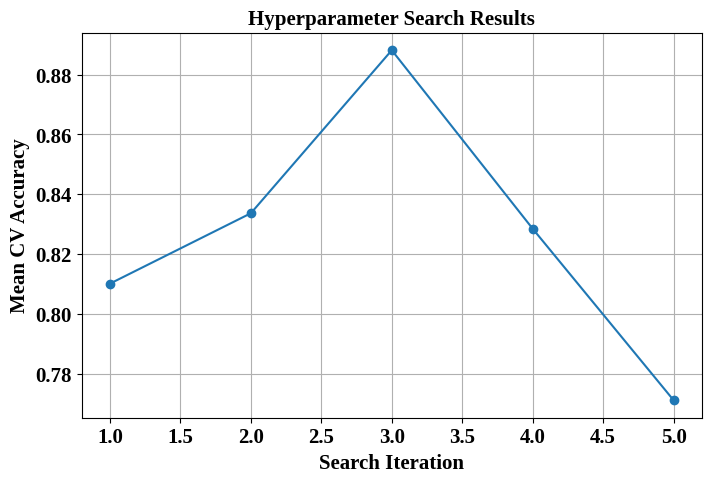

<Figure size 640x480 with 0 Axes>

In [25]:
# Plot Hyperparameter Search Results
results = random.cv_results_
plt.figure(figsize=(8,5))
plt.plot(range(1, len(results["mean_test_score"]) + 1),
         results["mean_test_score"],
         marker='o')
plt.xlabel("Search Iteration")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results")
plt.grid(True)
plt.show()
plt.savefig("HyperparameterSearchResults.eps", format="eps", bbox_inches="tight")

## Task 5: Retrain the model using the optimized hyperparameters.


In [26]:
# Get the best parameters
best_params = random.best_params_

# Build a new model
optimized_model = create_model(
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    activation=best_params["model__activation"],
    optimizer=best_params["model__optimizer"],
    learning_rate=best_params["model__learning_rate"],
    dropout_rate=best_params["model__dropout_rate"]
)

# Retrain on the full training set
start = time.time()
history_opt = optimized_model.fit(
    X_train,
    y_train_cat,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=1
)
optimized_time = time.time() - start


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7943 - loss: 0.5692
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8425 - loss: 0.4407
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8551 - loss: 0.4075
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8600 - loss: 0.3891
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8667 - loss: 0.3711
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8704 - loss: 0.3590
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8738 - loss: 0.3522
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8761 - loss: 0.3441
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8785 - loss: 0.3381
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8819 - loss: 0.3312
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8836 - loss: 0.3257
Epoch 12/30
1875/1875 ━━━━━━━

## Taask 6: Evaluate the optimized model on the testing dataset.


In [27]:
# Evaluate optimized model
pred = optimized_model.predict(X_test)
pred = np.argmax(pred, axis=1)
optimized_acc = accuracy_score(y_test, pred)
optimized_precision = precision_score(
    y_test, pred, average="weighted"
)
optimized_recall = recall_score(
    y_test, pred, average="weighted"
)
optimized_f1 = f1_score(
    y_test, pred, average="weighted"
)
print("Optimized Accuracy :", optimized_acc)
print("Precision          :", optimized_precision)
print("Recall             :", optimized_recall)
print("F1 Score           :", optimized_f1)
print(classification_report(y_test, pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Accuracy : 0.8749
Precision          : 0.8794368902991926
Recall             : 0.8749
F1 Score           : 0.8756891487856489
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1000
           1       0.99      0.96      0.98      1000
           2       0.80      0.77      0.78      1000
           3       0.87      0.89      0.88      1000
           4       0.73      0.86      0.79      1000
           5       0.98      0.95      0.96      1000
           6       0.66      0.71      0.68      1000
           7       0.94      0.96      0.95      1000
           8       0.98      0.97      0.97      1000
           9       0.95      0.96      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.88     10000
weighted avg       0.88      0.87      0.88     10000



## Task 7: Compare the optimized model with the baseline model.

In [35]:
import pandas as pd
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"],
    "Baseline": [
        baseline_acc,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_time
    ],
    "Optimized": [
        optimized_acc,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_time
    ]
})

comparison.head()

,Metric,Baseline,Optimized
0,Accuracy,0.889200,0.874900
1,Precision,0.888927,0.879437
2,Recall,0.889200,0.874900
3,F1 Score,0.888653,0.875689
4,Training Time (s),125.300847,162.061677


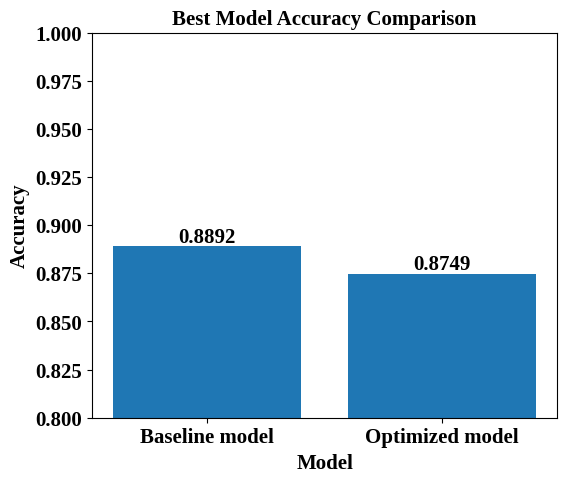

<Figure size 640x480 with 0 Axes>

In [37]:
models = ["Baseline model", "Optimized model"]
accuracies = [baseline_acc, optimized_acc]

plt.figure(figsize=(6,5))
plt.bar(models, accuracies)

plt.title("Best Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")

plt.ylim(0.8, 1.0)
plt.show()
plt.savefig("BestModelAccuracyComparison.eps", format="eps", bbox_inches="tight")